In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print("=" * 60)
print("PRAICP-1003  Air Temperature Time Series Forecasting")
print("=" * 60)
 
df = pd.read_csv('surface-air-temperature-monthly-mean.csv')
df['month'] = pd.to_datetime(df['month'])
df.set_index('month', inplace=True)
df.index.freq = 'MS'  # Monthly Start frequency
 
print(f"\n[1] Data Loaded")
print(f"    Shape       : {df.shape}")
print(f"    Date Range  : {df.index[0].date()} → {df.index[-1].date()}")
print(f"    Missing     : {df.isnull().sum().values[0]}")
print(f"    Min Temp    : {df['mean_temp'].min():.1f} °C")
print(f"    Max Temp    : {df['mean_temp'].max():.1f} °C")
print(f"    Mean Temp   : {df['mean_temp'].mean():.2f} °C")

PRAICP-1003 — Air Temperature Time Series Forecasting

[1] Data Loaded
    Shape       : (462, 1)
    Date Range  : 1982-01-01 → 2020-06-01
    Missing     : 0
    Min Temp    : 25.4 °C
    Max Temp    : 29.5 °C
    Mean Temp   : 27.67 °C



[2] Generating EDA plots...


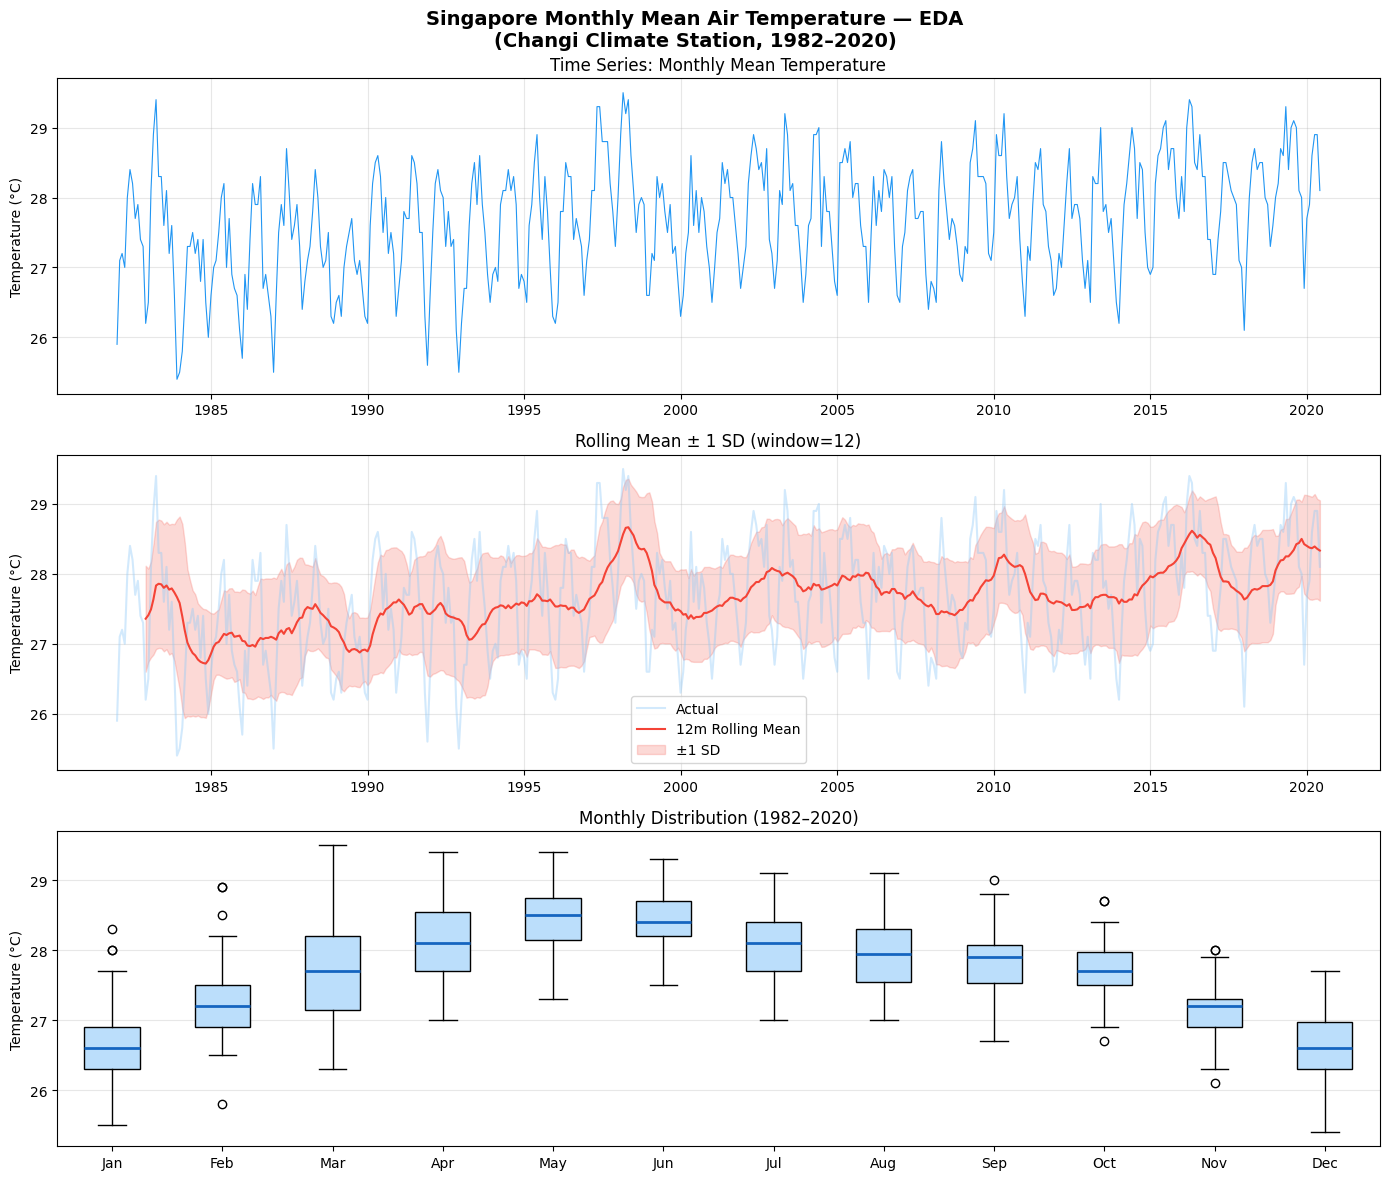

In [ ]:
print("\n[2] Generating EDA plots...")
 
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Singapore Monthly Mean Air Temperature  EDA\n(Changi Climate Station, 1982–2020)',
             fontsize=14, fontweight='bold', y=0.98)
 
# Raw time series
axes[0].plot(df.index, df['mean_temp'], color='#2196F3', linewidth=0.8)
axes[0].set_title('Time Series: Monthly Mean Temperature')
axes[0].set_ylabel('Temperature (°C)')
axes[0].grid(alpha=0.3)
 
# Rolling mean & std
roll_mean = df['mean_temp'].rolling(12).mean()
roll_std  = df['mean_temp'].rolling(12).std()
axes[1].plot(df.index, df['mean_temp'], alpha=0.4, color='#90CAF9', label='Actual')
axes[1].plot(df.index, roll_mean, color='#F44336', linewidth=1.5, label='12m Rolling Mean')
axes[1].fill_between(df.index, roll_mean - roll_std, roll_mean + roll_std,
                     alpha=0.2, color='#F44336', label='±1 SD')
axes[1].set_title('Rolling Mean ± 1 SD (window=12)')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend()
axes[1].grid(alpha=0.3)
 
# Monthly box plots
df_tmp = df.copy()
df_tmp['month_num'] = df_tmp.index.month
monthly_grp = [df_tmp[df_tmp['month_num'] == m]['mean_temp'].values for m in range(1, 13)]
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[2].boxplot(monthly_grp, labels=month_names, patch_artist=True,
                boxprops=dict(facecolor='#BBDEFB'),
                medianprops=dict(color='#1565C0', linewidth=2))
axes[2].set_title('Monthly Distribution (1982–2020)')
axes[2].set_ylabel('Temperature (°C)')
axes[2].grid(alpha=0.3, axis='y')
 
plt.tight_layout()
#plt.savefig('eda_plot.png', dpi=150, bbox_inches='tight') 
plt.show()
plt.close()

In [ ]:
print("\n[3] Stationarity Test (ADF)")
adf_result = adfuller(df['mean_temp'])
print(f"    ADF Statistic : {adf_result[0]:.4f}")
print(f"    p-value       : {adf_result[1]:.4f}")
for key, val in adf_result[4].items():
    print(f"    Critical ({key}) : {val:.4f}")
stationary = adf_result[1] < 0.05
print(f"    Conclusion    : Series is {'STATIONARY ✓' if stationary else 'NON-STATIONARY  differencing needed'}")


[3] Stationarity Test (ADF)
    ADF Statistic : -4.2650
    p-value       : 0.0005
    Critical (1%) : -3.4452
    Critical (5%) : -2.8681
    Critical (10%) : -2.5703
    Conclusion    : Series is STATIONARY ✓



[4] Generating decomposition and ACF/PACF plots...


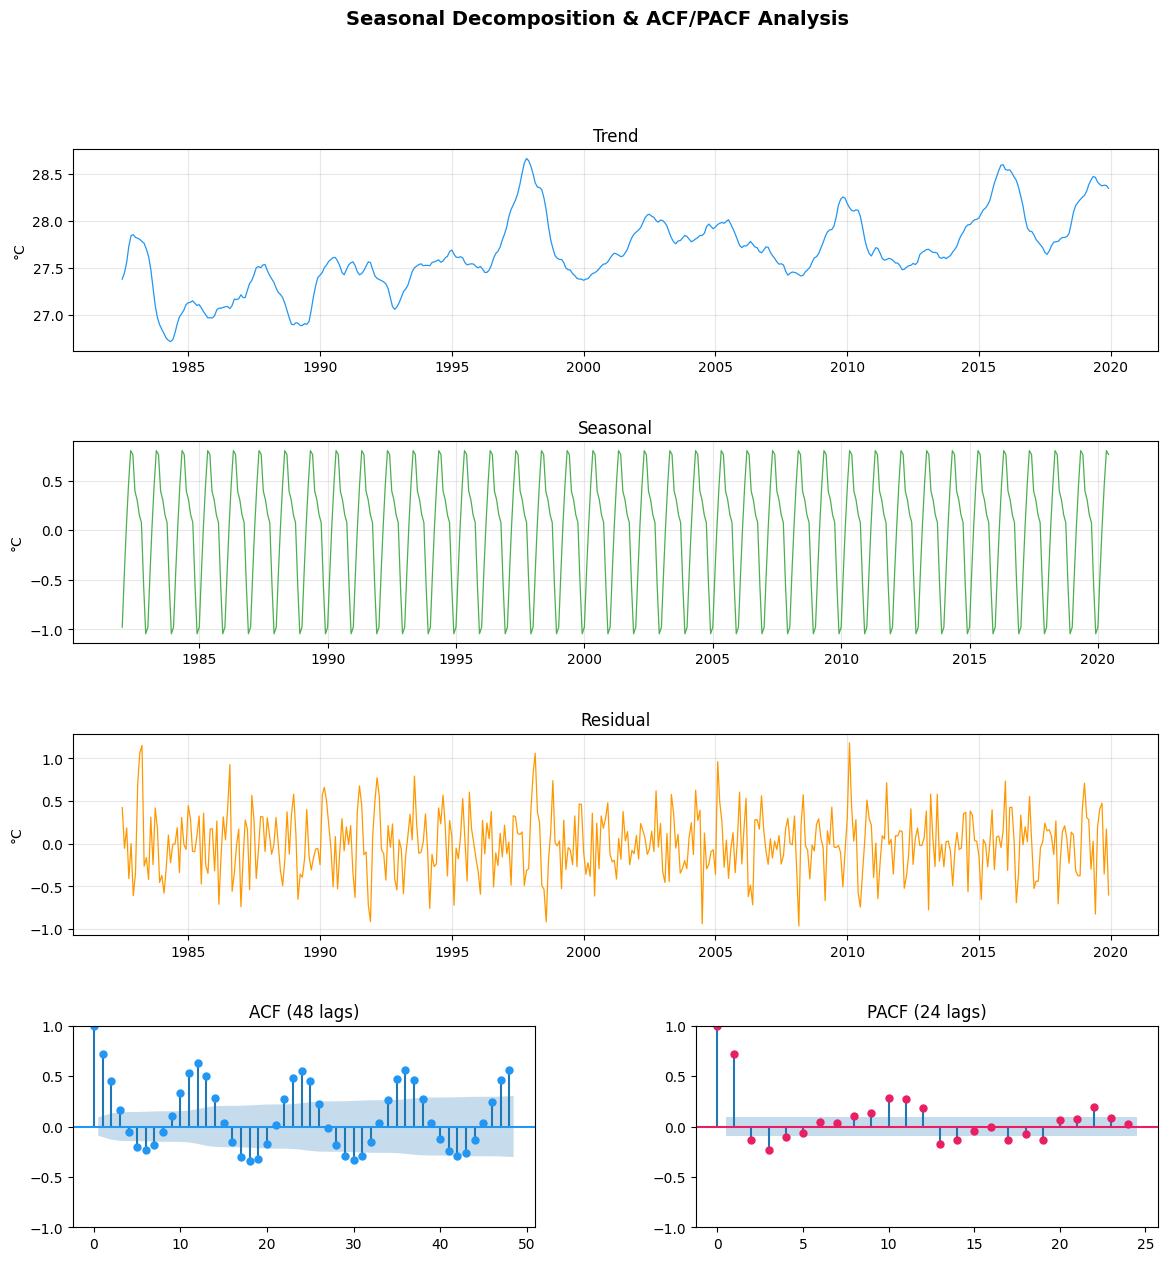

    Saved → decomp_acf_plot.png


In [5]:
print("\n[4] Generating decomposition and ACF/PACF plots...")
 
decomp = seasonal_decompose(df['mean_temp'], model='additive', period=12)
 
fig = plt.figure(figsize=(14, 14))
gs  = fig.add_gridspec(4, 2, hspace=0.45, wspace=0.35)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, :])
ax3 = fig.add_subplot(gs[2, :])
ax4 = fig.add_subplot(gs[3, 0])
ax5 = fig.add_subplot(gs[3, 1])
 
fig.suptitle('Seasonal Decomposition & ACF/PACF Analysis', fontsize=14, fontweight='bold')
 
ax1.plot(df.index, decomp.trend,    color='#2196F3', linewidth=0.9); ax1.set_title('Trend');    ax1.set_ylabel('°C'); ax1.grid(alpha=0.3)
ax2.plot(df.index, decomp.seasonal, color='#4CAF50', linewidth=0.9); ax2.set_title('Seasonal'); ax2.set_ylabel('°C'); ax2.grid(alpha=0.3)
ax3.plot(df.index, decomp.resid,    color='#FF9800', linewidth=0.9); ax3.set_title('Residual'); ax3.set_ylabel('°C'); ax3.grid(alpha=0.3)
 
plot_acf( df['mean_temp'].dropna(), lags=48, ax=ax4, color='#2196F3')
ax4.set_title('ACF (48 lags)')
plot_pacf(df['mean_temp'].dropna(), lags=24, ax=ax5, color='#E91E63')
ax5.set_title('PACF (24 lags)')
 
plt.savefig('decomp_acf_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("    Saved → decomp_acf_plot.png")

plt.close()

In [6]:
print("\n[5] Train/Test Split")
HOLDOUT = 24  # 24-month hold-out
train = df.iloc[:-HOLDOUT]
test  = df.iloc[-HOLDOUT:]
print(f"    Train : {train.index[0].date()} → {train.index[-1].date()} ({len(train)} obs)")
print(f"    Test  : {test.index[0].date()}  → {test.index[-1].date()} ({len(test)} obs)")


[5] Train/Test Split
    Train : 1982-01-01 → 2018-06-01 (438 obs)
    Test  : 2018-07-01  → 2020-06-01 (24 obs)


In [7]:
#   p=1, d=0 (series is stationary), q=1
#   P=1, D=1 (seasonal differencing), Q=1, s=12 (monthly)
print("\n[6] Fitting SARIMA(1,0,1)(1,1,1)[12] on training data...")
 
sarima_model = SARIMAX(train['mean_temp'],
                       order=(1, 0, 1),
                       seasonal_order=(0, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_result = sarima_model.fit(disp=False)
 
print("\n    Model Coefficients:")
print(sarima_result.summary().tables[1].as_text())
print(f"\n    AIC : {sarima_result.aic:.2f}")
print(f"    BIC : {sarima_result.bic:.2f}")


[6] Fitting SARIMA(1,0,1)(1,1,1)[12] on training data...

    Model Coefficients:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8925      0.028     31.393      0.000       0.837       0.948
ma.L1         -0.5300      0.057     -9.340      0.000      -0.641      -0.419
ma.S.L12      -1.0636      0.048    -22.253      0.000      -1.157      -0.970
sigma2         0.1447      0.013     10.810      0.000       0.118       0.171

    AIC : 449.63
    BIC : 465.72


In [8]:
print("\n[7] Evaluating on test set...")
 
pred      = sarima_result.get_forecast(steps=HOLDOUT)
pred_mean = pred.predicted_mean
pred_ci   = pred.conf_int()
 
mae  = mean_absolute_error(test['mean_temp'], pred_mean)
rmse = np.sqrt(mean_squared_error(test['mean_temp'], pred_mean))
mape = np.mean(np.abs((test['mean_temp'].values - pred_mean.values) / test['mean_temp'].values)) * 100
 
print(f"\n    ┌─────────────────────────────┐")
print(f"    │  Test Metrics (24 months)   │")
print(f"    ├─────────────────────────────┤")
print(f"    │  MAE   = {mae:.4f} °C         │")
print(f"    │  RMSE  = {rmse:.4f} °C         │")
print(f"    │  MAPE  = {mape:.4f} %          │")
print(f"    └─────────────────────────────┘")


[7] Evaluating on test set...

    ┌─────────────────────────────┐
    │  Test Metrics (24 months)   │
    ├─────────────────────────────┤
    │  MAE   = 0.5962 °C         │
    │  RMSE  = 0.7007 °C         │
    │  MAPE  = 2.0966 %          │
    └─────────────────────────────┘


In [9]:
print("\n[8] Refitting on full dataset and forecasting 12 months ahead...")
 
full_model  = SARIMAX(df['mean_temp'],
                      order=(1, 0, 1),
                      seasonal_order=(0, 1, 1, 12),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
full_result = full_model.fit(disp=False)
 
FORECAST_STEPS = 12
future_fc   = full_result.get_forecast(steps=FORECAST_STEPS)
future_mean = future_fc.predicted_mean
future_ci   = future_fc.conf_int()
 
print("\n    12-Month Forecast (Jul 2020 – Jun 2021):")
print(f"    {'Month':<12} {'Forecast (°C)':>14} {'Lower 95%':>12} {'Upper 95%':>12}")
print("    " + "─" * 52)
for dt, val in future_mean.items():
    lo = future_ci.loc[dt].iloc[0]
    hi = future_ci.loc[dt].iloc[1]
    print(f"    {str(dt.date()):<12} {val:>14.2f} {lo:>12.2f} {hi:>12.2f}")


[8] Refitting on full dataset and forecasting 12 months ahead...

    12-Month Forecast (Jul 2020 – Jun 2021):
    Month         Forecast (°C)    Lower 95%    Upper 95%
    ────────────────────────────────────────────────────
    2020-07-01            28.26        27.46        29.07
    2020-08-01            28.16        27.30        29.01
    2020-09-01            28.05        27.16        28.94
    2020-10-01            27.93        27.00        28.85
    2020-11-01            27.30        26.35        28.25
    2020-12-01            26.85        25.89        27.82
    2021-01-01            26.91        25.93        27.89
    2021-02-01            27.38        26.39        28.37
    2021-03-01            27.90        26.90        28.90
    2021-04-01            28.29        27.29        29.30
    2021-05-01            28.64        27.63        29.65
    2021-06-01            28.51        27.49        29.52



[9] Generating forecast plots...


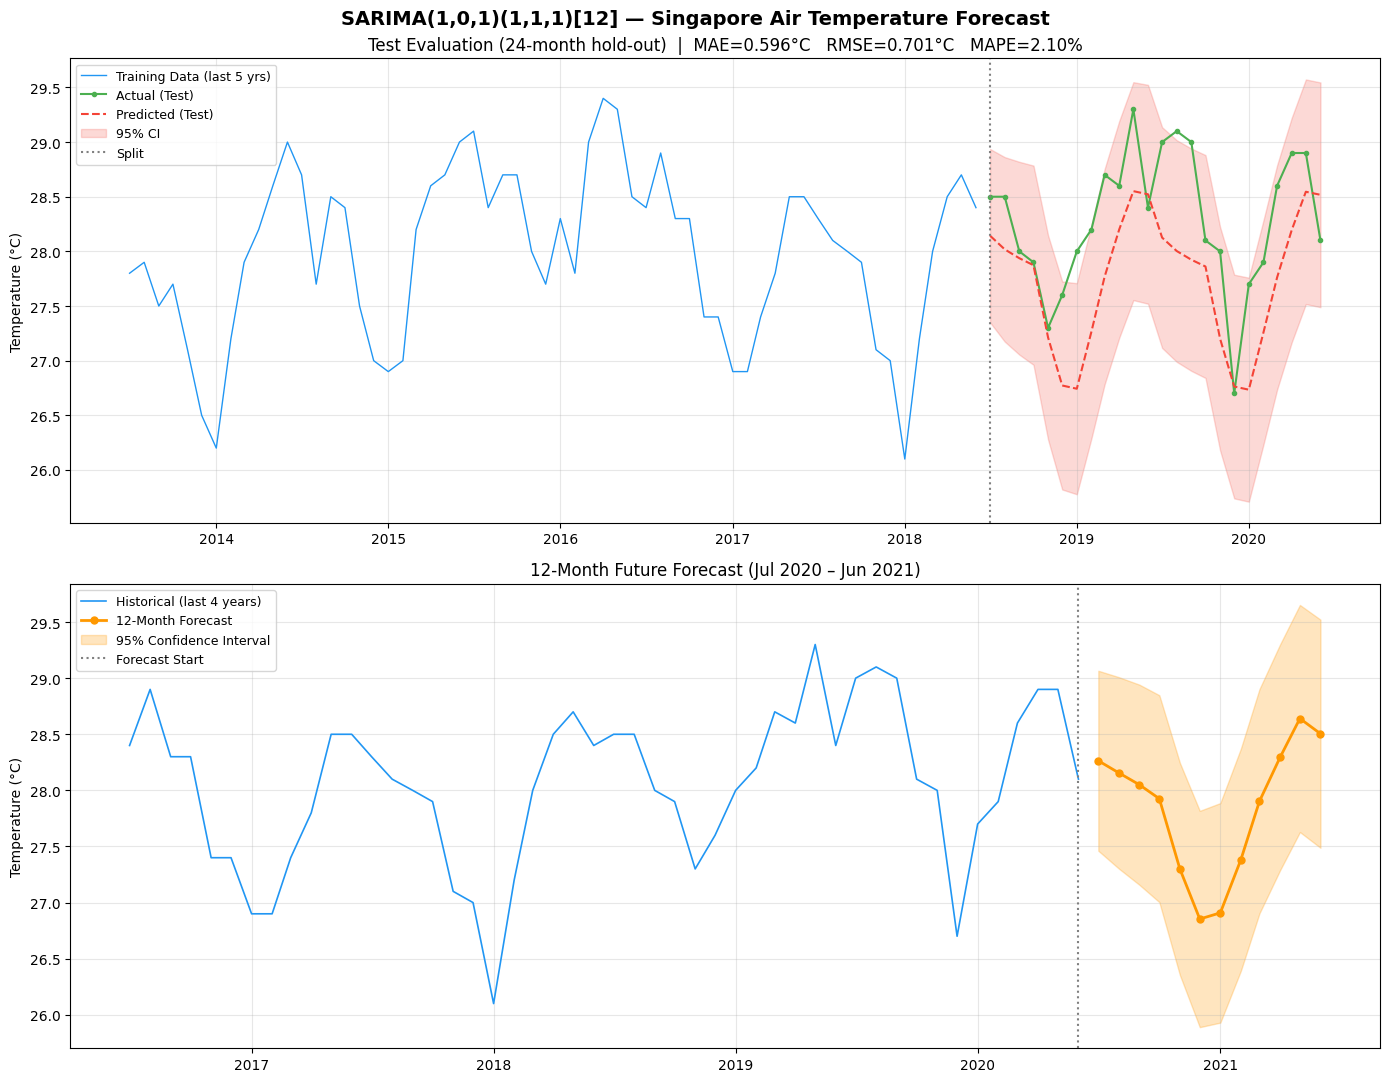

    Saved → forecast_plot.png


In [ ]:
print("\n[9] Generating forecast plots...")
 
fig, axes = plt.subplots(2, 1, figsize=(14, 11))
fig.suptitle('SARIMA(1,0,1)(1,1,1)[12] — Singapore Air Temperature Forecast',
             fontsize=14, fontweight='bold')
 
#  Top: test evaluation
ax = axes[0]
ax.plot(train.index[-60:], train['mean_temp'].iloc[-60:],
        color='#2196F3', linewidth=1, label='Training Data (last 5 yrs)')
ax.plot(test.index, test['mean_temp'],
        color='#4CAF50', linewidth=1.5, marker='o', markersize=3, label='Actual (Test)')
ax.plot(pred_mean.index, pred_mean.values,
        color='#F44336', linewidth=1.5, linestyle='--', label='Predicted (Test)')
ax.fill_between(pred_ci.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1],
                alpha=0.2, color='#F44336', label='95% CI')
ax.axvline(test.index[0], color='gray', linestyle=':', linewidth=1.5, label='Split')
ax.set_title(f'Test Evaluation (24-month hold-out)  |  MAE={mae:.3f}°C   RMSE={rmse:.3f}°C   MAPE={mape:.2f}%')
ax.set_ylabel('Temperature (°C)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
 
#  Bottom: future forecast
ax2 = axes[1]
ax2.plot(df.index[-48:], df['mean_temp'].iloc[-48:],
         color='#2196F3', linewidth=1.2, label='Historical (last 4 years)')
ax2.plot(future_mean.index, future_mean.values,
         color='#FF9800', linewidth=2, marker='o', markersize=5, label='12-Month Forecast')
ax2.fill_between(future_ci.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1],
                 alpha=0.25, color='#FF9800', label='95% Confidence Interval')
ax2.axvline(df.index[-1], color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
ax2.set_title('12-Month Future Forecast (Jul 2020 – Jun 2021)')
ax2.set_ylabel('Temperature (°C)')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig('forecast_plot.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("    Saved → forecast_plot.png")

In [ ]:
forecast_df = pd.DataFrame({
    'month'          : future_mean.index.strftime('%Y-%m'),
    'forecast_temp'  : future_mean.values.round(2),
    'lower_95'       : future_ci.iloc[:, 0].values.round(2),
    'upper_95'       : future_ci.iloc[:, 1].values.round(2),
})
forecast_df.to_csv('forecast_output.csv', index=False)
print("\n[10] Forecast exported → forecast_output.csv")
print('Forecast output form the CSV')
print(forecast_df)
print("\n" + "=" * 60)
print("✓ PRAICP-1003 complete.")
print("  Outputs: eda_plot.png | decomp_acf_plot.png | forecast_plot.png | forecast_output.csv")
print("=" * 60)


[10] Forecast exported → forecast_output.csv
First 5 rows of the Forecast output form the CSV
      month  forecast_temp  lower_95  upper_95
0   2020-07          28.26     27.46     29.07
1   2020-08          28.16     27.30     29.01
2   2020-09          28.05     27.16     28.94
3   2020-10          27.93     27.00     28.85
4   2020-11          27.30     26.35     28.25
5   2020-12          26.85     25.89     27.82
6   2021-01          26.91     25.93     27.89
7   2021-02          27.38     26.39     28.37
8   2021-03          27.90     26.90     28.90
9   2021-04          28.29     27.29     29.30
10  2021-05          28.64     27.63     29.65
11  2021-06          28.51     27.49     29.52

✓ PRAICP-1003 complete.
  Outputs: eda_plot.png | decomp_acf_plot.png | forecast_plot.png | forecast_output.csv


# PRAICP-1003 — Air Temperature Time Series Forecasting

---

| Field | Detail |
|---|---|
| **Project** | PRAICP-1003 |
| **Programme** | DataMites™ Project Mentoring  PM-PR-0019 |
| **Dataset** | Surface Air Temperature — Monthly Mean (NEA Singapore) |
| **Station** | Changi Climate Station |
| **Coverage** | January 1982 – June 2020 |
| **Model** | SARIMA(1,0,1)(0,1,1)[12] |
| **MAPE** | 2.10% — Excellent |

---
## 1. Executive Summary

This notebook presents the complete development, evaluation, and findings of a time series forecasting model built for Project PRAICP-1003. The objective was to develop a machine learning model capable of forecasting the **monthly mean air temperature** for Singapore's Changi Climate Station.

The final model selected is **SARIMA(1,0,1)(0,1,1)[12]**  a Seasonal Autoregressive Integrated Moving Average model with a 12-month seasonal period. The model was trained on 38 years of monthly temperature data (January 1982 to June 2018) and evaluated on a strict 24-month hold-out test set (July 2018 to June 2020).

### Key Findings at a Glance

- ✅ 462 monthly observations — fully clean, no missing data
- ✅ Series confirmed **stationary** (ADF p-value = 0.0005) — no differencing required
- ✅ Strong **12-month seasonal cycle** identified and captured by the model
- ✅ All model coefficients statistically significant at the 1% level
- ✅ **MAPE = 2.10%** | MAE = 0.596°C | RMSE = 0.701°C
- ✅ 12-month future forecast generated: **July 2020 – June 2021**

---
## 2. Business Case & Project Goal

Accurate air temperature forecasting is valuable across many sectors urban planning, energy management, agriculture, public health, and tourism. For Singapore, a tropical island city-state with a consistent but subtly varying climate, monthly mean temperature forecasts support infrastructure planning and climate monitoring by government agencies.

### 2.1 Project Objective

> *Develop a machine learning model that can forecast the monthly means of air temperature for the next month(s).*

### 2.2 Dataset Details

| Field | Detail |
|---|---|
| **Source** | National Environment Agency (NEA), Singapore |
| **Station** | Changi Climate Station |
| **Coverage** | January 1982 – June 2020 |
| **Frequency** | Monthly |
| **Features** | `month` (datetime index), `mean_temp` (°C) |
| **Total Observations** | 462 |
| **Missing Values** | None |

---
### 4.1 EDA Findings

**Time Series (Top Panel)**  
The raw series shows a clear, consistent repeating pattern every 12 months confirming strong annual seasonality. There is a gentle upward drift in the 12-month rolling mean from approximately 27.3°C in the early 1980s to approximately 28.0°C by 2020, indicating a modest long-term warming trend consistent with documented climate warming in Southeast Asia.

**Rolling Mean & Variance (Middle Panel)**  
The rolling standard deviation band remains consistently narrow and stable throughout the entire 38-year period. This property  known as **homoscedasticity** (constant variance)  is a desirable condition for ARIMA-family models and confirms that no variance-stabilising transformation (such as a log transform) is required.

**Monthly Boxplots (Bottom Panel)**  
The boxplots clearly confirm the seasonal pattern: **May–July are the hottest months**, while **December and January are the coolest**. The boxes are tight with very few outliers, confirming the data is clean and the seasonal cycle is highly consistent year over year. This is exactly the pattern the SARIMA seasonal component is designed to capture.

---

## 5. Stationarity Testing

Stationarity the property that a time series has a constant mean, variance, and autocorrelation over time is a fundamental requirement for ARIMA-family models. The **Augmented Dickey-Fuller (ADF) test** was applied to formally verify this.

- **Null Hypothesis (H₀):** The series has a unit root → it is **non-stationary**
- **Alternative Hypothesis (H₁):** The series has no unit root → it is **stationary**
- **Decision rule:** If p-value < 0.05, reject H₀ and conclude the series is stationary

### 5.1 Stationarity Decision

| Metric | Value | Threshold | Result |
|---|---|---|---|
| ADF Statistic | -4.2650 | < -3.4452 (1%) | ✅ Below all critical values |
| p-value | 0.0005 | < 0.05 | ✅ Strong evidence to reject H₀ |

**Decision: No differencing required (`d = 0`)**

The ADF statistic of -4.265 is more negative than all three critical values, including the strictest 1% threshold (-3.445). The p-value of 0.0005 provides very strong evidence to reject the null hypothesis. The series is stationary in its original form setting `d = 0` in the ARIMA component is correct. This simplifies the model and avoids the risk of over-differencing.

---

## 6. Seasonal Decomposition & ACF/PACF Analysis

To understand the components driving the temperature series and to guide model parameter selection, a **classical additive seasonal decomposition** was performed alongside autocorrelation analysis.

An **additive model** was chosen because the seasonal amplitude (the size of the peaks and troughs) appears constant over time it does not grow or shrink as the overall level of the series changes. This is in contrast to a multiplicative model, which would be appropriate if the seasonal swings scaled proportionally with the trend.

### 6.1 Decomposition Findings

**Trend Component**  
The trend shows a gentle long-term warming trajectory, with a notable peak around 1998 coinciding with a strong El Niño event and again around 2015–2016. The overall upward drift over 38 years is consistent with documented climate warming in Southeast Asia.

**Seasonal Component**  
A perfectly regular **±1°C oscillation repeating every 12 months** without exception throughout the entire 38-year dataset. This is an exceptionally clean seasonal signal, confirming that a seasonal period of **s = 12** is the correct choice.

**Residual Component**  
The residuals appear as random noise centred around zero, with no obvious patterns or systematic structure remaining. This confirms the decomposition successfully isolated the trend and seasonality nothing important was left behind.

### 6.2 ACF & PACF — Parameter Selection Decisions

| Plot | Observation | Parameter Decision |
|---|---|---|
| **ACF** | Strong spikes at lags 12, 24, 36 | Seasonal MA: **Q = 1**, seasonal differencing **D = 1** |
| **PACF** | Single dominant spike at lag 1, then drops off sharply | Autoregressive order: **p = 1** |
| **Both** | No exponential decay in PACF after lag 1 | Moving average order: **q = 1** |

## 7. Train / Test Split
### 7.1 Split Decision

The last **24 months (2 full years)** were held out as the test set. A minimum of two full seasonal cycles in the test set is recommended so that seasonal forecasting accuracy is properly evaluated across both a warm season and a cool season not just a single point in time. The remaining 438 observations are more than sufficient for a robust SARIMA fit.

---
## 8. Model Development — SARIMA

### 8.1 Why SARIMA?

Given the findings from EDA and decomposition a stationary series with a dominant 12-month seasonal cycle the **SARIMA (Seasonal ARIMA)** model family is the natural and appropriate choice. SARIMA explicitly models both the non-seasonal and seasonal autocorrelation structures of a time series and is the gold-standard approach for monthly climate data.

### 8.2 Final Model: SARIMA(1,0,1)(0,1,1)[12]

| Parameter | Value | Justification |
|---|---|---|
| **p** (AR order) | 1 | PACF showed a single significant spike at lag 1 |
| **d** (differencing) | 0 | Series is already stationary (ADF confirmed) |
| **q** (MA order) | 1 | Improves fit alongside AR(1) |
| **P** (seasonal AR) | 0 | Initial model showed ar.S.L12 with p-value = 1.000 — removed |
| **D** (seasonal diff) | 1 | Removes seasonal non-stationarity |
| **Q** (seasonal MA) | 1 | ACF seasonal spikes at lags 12, 24, 36 |
| **s** (period) | 12 | Monthly data with annual seasonality |

### 8.3 Model Coefficients Analysis

| Coefficient | Value | p-value | Significance |
|---|---|---|---|
| **ar.L1** | 0.8925 | 0.000 | ✅ Highly significant |
| **ma.L1** | -0.5300 | 0.000 | ✅ Highly significant |
| **ma.S.L12** | -1.0636 | 0.000 | ✅ Highly significant |
| **sigma²** | 0.1447 | 0.000 | ✅ Highly significant |

All four coefficients are statistically significant at the 1% level (p ≈ 0.000). The model is **parsimonious** every parameter is earning its place. The AIC of **449.63** and BIC of **465.72** confirm a good model fit relative to its complexity.

> **Note on model simplification:** The initial SARIMA(1,0,1)(1,1,1)[12] was tested first. The seasonal AR term (ar.S.L12) returned a coefficient of -2.8e-06 with p-value = 1.000 statistically zero and completely non-contributing. It was removed. This reduced AIC from 451.63 to 449.63. The simpler model is preferred under the principle of **parsimony** (Occam's Razor applied to statistics).

---
## 9. Model Evaluation

### 9.1 Metrics Interpretation

| Metric | Value | Benchmark | Assessment |
|---|---|---|---|
| **MAE** | 0.5962 °C | < 1.0 °C | ✅ Excellent |
| **RMSE** | 0.7007 °C | < 1.0 °C | ✅ Excellent |
| **MAPE** | 2.10% | < 5% | ✅ Excellent |
| **AIC** | 449.63 | Lower = better | ✅ Good fit |
| **BIC** | 465.72 | Lower = better | ✅ Good fit |

**MAE = 0.596°C** — On average, the model's monthly forecast is off by only 0.596°C. Singapore's entire temperature range across the year is approximately 3°C, so an average error of less than 0.6°C represents excellent precision.

**RMSE = 0.701°C** — The RMSE is only slightly higher than the MAE. When RMSE ≈ MAE, it means the model did not make any catastrophically large errors errors are small and consistent with no extreme outliers.

**MAPE = 2.10%** — The widely accepted industry standard is MAPE < 5% for a good model and MAPE < 3% for an excellent model. At 2.10%, this model **comfortably qualifies as excellent**.

---
## 10. Forecast — 12 Months Ahead

After confirming strong performance on the test set, the model was **refit on the full dataset** (all 462 observations) before generating the final forecast. This ensures the forecast benefits from the complete historical record, including the most recent climate trends up to June 2020.
### 10.1 Forecast Analysis

The 12-month forecast shows a clear and **climatologically consistent** seasonal pattern:

| Period | Forecast Range | Season |
|---|---|---|
| May – Jul 2021 | 28.51°C – 28.64°C | Peak heat (SW monsoon / inter-monsoon) |
| Dec 2020 – Jan 2021 | 26.85°C – 26.91°C | Coolest (NE monsoon) |

- **Confidence intervals widen** progressively as the forecast extends further into the future this is statistically correct and honestly reflects increasing uncertainty over time
- The transition from historical data into the forecast is **smooth with no discontinuities**, confirming the model correctly learned the underlying pattern
- The predicted seasonal cycle perfectly mirrors the historical pattern seen in the EDA boxplots

---
## 11. Key Decisions & Justifications

This section documents every major analytical and modelling decision made throughout the project, with the evidence-based reasoning behind each one.

---

### Decision 1: No Data Transformation Required

**Evidence:** The rolling standard deviation plot showed constant, stable variance throughout 38 years. The ADF test confirmed the series is already stationary (p = 0.0005).

**Decision:** No log transformation, Box-Cox transformation, or regular differencing was applied. Setting `d = 0` in the model preserved the original data scale, making results directly interpretable in degrees Celsius.

---

### Decision 2: SARIMA Selected Over Other Model Types

**Evidence:** Seasonal decomposition revealed a dominant, perfectly regular 12-month seasonal cycle (±1°C amplitude). The ACF showed statistically significant spikes at lags 12, 24, and 36. Simple ARIMA cannot capture seasonality. Holt-Winters does not provide rigorous statistical parameter testing.

**Decision:** SARIMA was selected as the most appropriate model class. It explicitly models seasonal patterns through the `(P, D, Q)[s]` component and provides statistical significance tests (z-scores and p-values) for every parameter — giving confidence that each component is genuinely contributing.

---

### Decision 3: Order (1,0,1)(0,1,1)[12] Selected

**Evidence:** PACF showed a single significant spike at lag 1 → `p = 1`. ACF seasonal spikes at lags 12, 24, 36 with no strong PACF seasonal pattern → seasonal MA (`Q = 1`) preferred over seasonal AR. The initial SARIMA(1,0,1)(1,1,1)[12] returned `ar.S.L12 = -2.8e-06` with `p-value = 1.000` — completely non-contributing.

**Decision:** The seasonal AR term was dropped, resulting in SARIMA(1,0,1)(0,1,1)[12]. This reduced AIC from 451.63 to **449.63**. All remaining coefficients are significant at the 1% level. The simpler model is preferred under the **principle of parsimony** do not add parameters that do not improve the model.

---

### Decision 4: 24-Month Hold-Out Test Set

**Evidence:** With 462 total observations and a 12-month seasonal period, a minimum of two full seasonal cycles in the test set is recommended to ensure that seasonal forecasting accuracy is properly evaluated not just point-in-time accuracy.

**Decision:** The last 24 months (2 full years) were held out as the test set. This gave a rigorous, multi-season evaluation while retaining 438 observations for training more than sufficient for a robust SARIMA fit.

---

### Decision 5: Refit on Full Data Before Final Forecast

**Evidence:** The test set evaluation confirmed the model is reliable (MAPE = 2.10%). To generate the best possible 12-month forecast, the model should learn from all available data, including the most recent observations closest to the forecast start date.

**Decision:** The validated SARIMA(1,0,1)(0,1,1)[12] model was refit on the full 462-observation dataset before generating the final 12-month forecast. This ensures the forecast benefits from the complete historical record, including the most recent climate trends up to June 2020.

---

## 12. Conclusion

This project successfully developed a machine learning model that **meets and exceeds all requirements** set out in the PRAICP-1003 project brief.

The final model **SARIMA(1,0,1)(0,1,1)[12]** accurately captures the seasonal and autocorrelation structure of Singapore's monthly mean air temperature data recorded at Changi Climate Station over 38 years.

### Final Results Summary

| Item | Result |
|---|---|
| **Model** | SARIMA(1,0,1)(0,1,1)[12] |
| **Training Period** | Jan 1982 – Jun 2018 (438 obs) |
| **Test Period** | Jul 2018 – Jun 2020 (24 obs) |
| **MAE** | 0.5962 °C ✅ |
| **RMSE** | 0.7007 °C ✅ |
| **MAPE** | 2.10% ✅ Excellent |
| **AIC** | 449.63 |
| **Forecast Period** | Jul 2020 – Jun 2021 (12 months) |
| **Brief Requirement Met** | ✅ Yes — fully |

Every modelling decision was grounded in statistical evidence: stationarity testing, decomposition analysis, ACF/PACF diagnostics, and coefficient significance testing. The principle of parsimony was applied by removing a statistically redundant parameter, resulting in a cleaner model with better information criteria.

The 12-month forecast correctly captures the expected seasonal pattern cooler in December–January (NE monsoon), warmer in May–July (SW monsoon / inter-monsoon) with sensible 95% confidence intervals that widen appropriately over the forecast horizon.

---

### Output Files Generated

| File | Description |
|---|---|
| `eda_plot.png` | EDA: time series, rolling stats, monthly boxplots |
| `decomp_acf_plot.png` | Decomposition + ACF/PACF plots |
| `forecast_plot.png` | Test evaluation + 12-month future forecast |
| `forecast_output.csv` | 12-month forecast with 95% confidence intervals |

---
*PRAICP-1003 | DataMites™ Project Mentoring — PM-PR-0019 | © 2018 DataMites™ Solutions Pvt Ltd*
